In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from prophet import Prophet

model = Prophet()
daily_data = pd.read_csv('daily_data.csv')

Importing plotly failed. Interactive plots will not work.


In [2]:
# daily_data.to_csv("daily_data.csv", index=False)

In [3]:
daily_data['Date'] = pd.to_datetime(daily_data['Date'] , format='%d-%m-%Y')
# df['date'] = pd.to_datetime(df['date'])

In [4]:
daily_data.drop(daily_data.index)

,Date,Total_Amount


In [5]:
daily_data

,Date,Total_Amount
0,2023-01-01,154893.75
1,2023-01-02,143228.24
2,2023-01-03,170905.52
3,2023-01-04,186552.23
4,2023-01-05,117197.17
...,...,...
495,2024-05-10,137093.54
496,2024-05-11,145953.58
497,2024-05-12,122724.78
498,2024-05-13,121858.01


In [6]:
print(type(daily_data))  # Should say: <class 'pandas.core.frame.DataFrame'>

<class 'pandas.core.frame.DataFrame'>


Text(0.5, 1.0, 'Simple Line Plot')

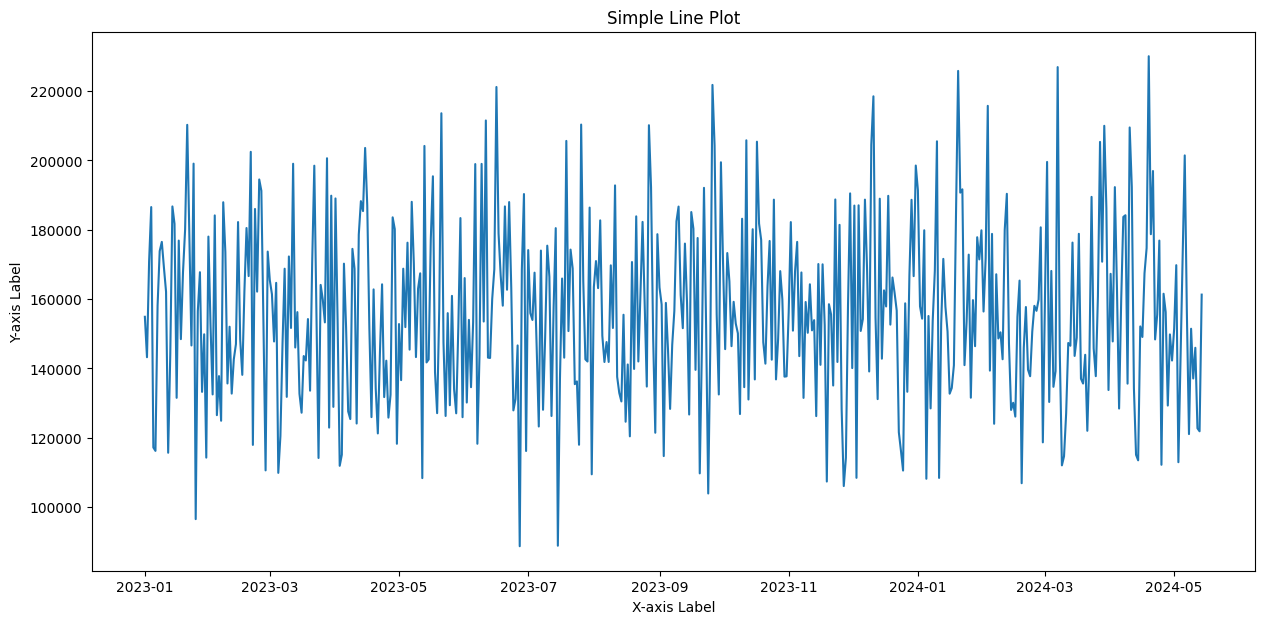

In [7]:
plt.figure(figsize=(15,7))
plt.plot( daily_data['Date'], daily_data['Total_Amount'] )
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.title('Simple Line Plot')

In [8]:
daily_data.rename(columns={'Date': 'ds', 'Total_Amount': 'y'}, inplace=True)

In [9]:
daily_data

,ds,y
0,2023-01-01,154893.75
1,2023-01-02,143228.24
2,2023-01-03,170905.52
3,2023-01-04,186552.23
4,2023-01-05,117197.17
...,...,...
495,2024-05-10,137093.54
496,2024-05-11,145953.58
497,2024-05-12,122724.78
498,2024-05-13,121858.01


In [10]:
daily_data['ds'] = pd.to_datetime(daily_data['ds'], dayfirst=True)

In [11]:
model.fit(daily_data)

10:46:49 - cmdstanpy - INFO - Chain [1] start processing
10:46:49 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
future = model.make_future_dataframe(periods=30)  # e.g., 30 days ahead
future

,ds
0,2023-01-01
1,2023-01-02
2,2023-01-03
3,2023-01-04
4,2023-01-05
...,...
525,2024-06-09
526,2024-06-10
527,2024-06-11
528,2024-06-12


In [13]:
forecast = model.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2023-01-01,155638.483779,124308.386619,186183.610213,155638.483779,155638.483779,-657.608525,-657.608525,-657.608525,-657.608525,-657.608525,-657.608525,0.0,0.0,0.0,154980.875254
1,2023-01-02,155641.104155,117998.618697,183309.286623,155641.104155,155641.104155,-3991.893797,-3991.893797,-3991.893797,-3991.893797,-3991.893797,-3991.893797,0.0,0.0,0.0,151649.210358
2,2023-01-03,155643.724531,119565.936379,186754.908349,155643.724531,155643.724531,-1277.264132,-1277.264132,-1277.264132,-1277.264132,-1277.264132,-1277.264132,0.0,0.0,0.0,154366.460399
3,2023-01-04,155646.344907,125266.482221,191072.218587,155646.344907,155646.344907,2508.592476,2508.592476,2508.592476,2508.592476,2508.592476,2508.592476,0.0,0.0,0.0,158154.937383
4,2023-01-05,155648.965283,123816.162897,190066.833240,155648.965283,155648.965283,799.338439,799.338439,799.338439,799.338439,799.338439,799.338439,0.0,0.0,0.0,156448.303723
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,2024-06-09,157011.793642,122841.491952,188840.440027,157011.785044,157011.801913,-657.608525,-657.608525,-657.608525,-657.608525,-657.608525,-657.608525,0.0,0.0,0.0,156354.185117
526,2024-06-10,157014.404719,120784.299383,187573.933565,157014.395448,157014.413418,-3991.893797,-3991.893797,-3991.893797,-3991.893797,-3991.893797,-3991.893797,0.0,0.0,0.0,153022.510922
527,2024-06-11,157017.015796,122119.127919,186649.285284,157017.005547,157017.024972,-1277.264132,-1277.264132,-1277.264132,-1277.264132,-1277.264132,-1277.264132,0.0,0.0,0.0,155739.751664
528,2024-06-12,157019.626873,125943.253455,190533.117852,157019.616092,157019.636692,2508.592476,2508.592476,2508.592476,2508.592476,2508.592476,2508.592476,0.0,0.0,0.0,159528.219349


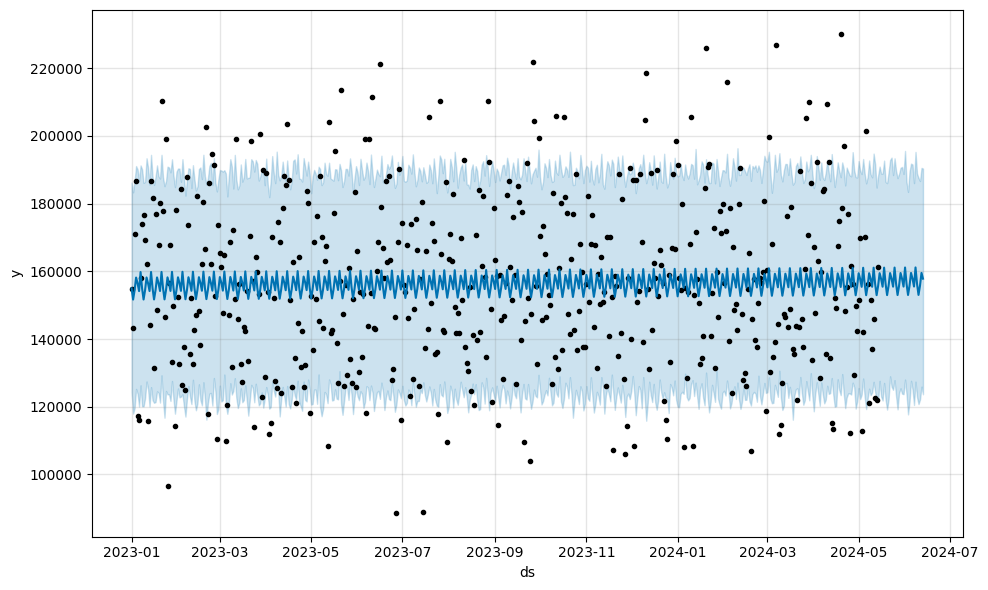

In [17]:
model.plot(forecast)
plt.show()

## Forcast Results form 15-05-2024 to 13-06-2024

In [18]:
result = forecast[['ds', 'yhat']].tail(30)

In [21]:
result.to_csv('forecaste table.csv' ,index = False)